### TASK 9. Coulomb staircase
First we import the necessary packages and libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from CBSetup import *
from myutils import *
from simulator import *

We can now build the setup for task 9 according to the CB.setup.pdf file. We set the parameters to a default value of:
- Gb = 50
- Gs = 1
- C = 1
- Cg = 0.01

In [30]:
Setup=CBSetup()
def setuptask9(Gb=50, Gs=1, C=1, Cg=0.01):
    #First we create the setup
    #two leads
    Setup.add_lead('LeadLeft')
    Setup.add_lead('LeadRight')

    #two islands
    Setup.add_island('Island1')
    Setup.add_island('Island2')

    #We connect the leads to the islands with 3 tunnel junctions
    Setup.add_junctionBIL('Junction1','Island1','LeadLeft',Gb,C)
    Setup.add_junctionBTI('Junction2','Island1','Island2',Gb,C)
    Setup.add_junctionBIL('Junction3','Island2','LeadRight',Gs,C)

    #We add gates to the islands
    Setup.add_gate('Gate_1', 'Island1', Cg)
    Setup.add_gate('Gate_2', 'Island2', Cg)

    Setup.finish()

## a)
We can now do exercise a). We set the temperature T = 10e-3 and the gate voltages Volt_Gate_1 = 0 and Volt_Gate_2 = 0. 
We run the voltage difference between the leads from 0 to Vmax in Numsteps steps during the simulation. We can then plot the I-V curve for this setup, varying Gb = 50,100,200 en 400.

In [59]:
Numsteps = 100
Vmax = 5
timeinterval = 10000
zeros = np.zeros(2)
currents = []
for Gb in [50, 100, 200, 400]:
    Setup=CBSetup()
    setuptask9(Gb=Gb)
    Setup.temperature = 10e-3
    #initialize the system with zero voltages and zero charges
    Setup.set_gate_voltage('Gate_1', 0)
    Setup.set_gate_voltage('Gate_2', 0)
    Setup.set_lead_voltage('LeadLeft', 0)
    Setup.set_lead_voltage('LeadRight', 0)

    runcurrents = Setup.runit(
        Numsteps,
        zeros,
        zeros,
        np.array([Vmax / 2, -Vmax / 2]),
        zeros,
        timeinterval=timeinterval,
        debug=True,
    )
    currents.append(np.array(runcurrents)[:,0]) #I am only interested in the current through the left lead, which is the first column of runcurrents

currents = np.array(currents)
print(currents)
print(currents.shape)

Run 1
CPU time: 0.0 Simulated time: 285006517757.8 Events: 1 Cache: 1
Run 2
CPU time: 0.0 Simulated time: 726229431996.8 Events: 2 Cache: 2
Run 3
CPU time: 0.0 Simulated time: 278928759381.4 Events: 2 Cache: 2
Run 4
CPU time: 0.0 Simulated time: 58562048330.8 Events: 2 Cache: 2
Run 5
CPU time: 0.0 Simulated time: 966941058.6 Events: 2 Cache: 2
Run 6
CPU time: 0.0 Simulated time: 2085126894.6 Events: 2 Cache: 2
Run 7
CPU time: 0.0 Simulated time: 314294020.5 Events: 3 Cache: 3
Run 8
CPU time: 0.0 Simulated time: 162714961.5 Events: 2 Cache: 2
Run 9
CPU time: 0.0 Simulated time: 46638484.0 Events: 3 Cache: 3
Run 10
CPU time: 0.0 Simulated time: 7185219.9 Events: 3 Cache: 3
Run 11
CPU time: 0.0 Simulated time: 2429878.3 Events: 3 Cache: 3
Run 12
CPU time: 0.0 Simulated time: 339851.3 Events: 2 Cache: 2
Run 13
CPU time: 0.0 Simulated time: 54479.1 Events: 2 Cache: 2
Run 14
CPU time: 0.0 Simulated time: 21304.4 Events: 8 Cache: 4
Run 15
CPU time: 0.0 Simulated time: 12075.5 Events: 18 Cache

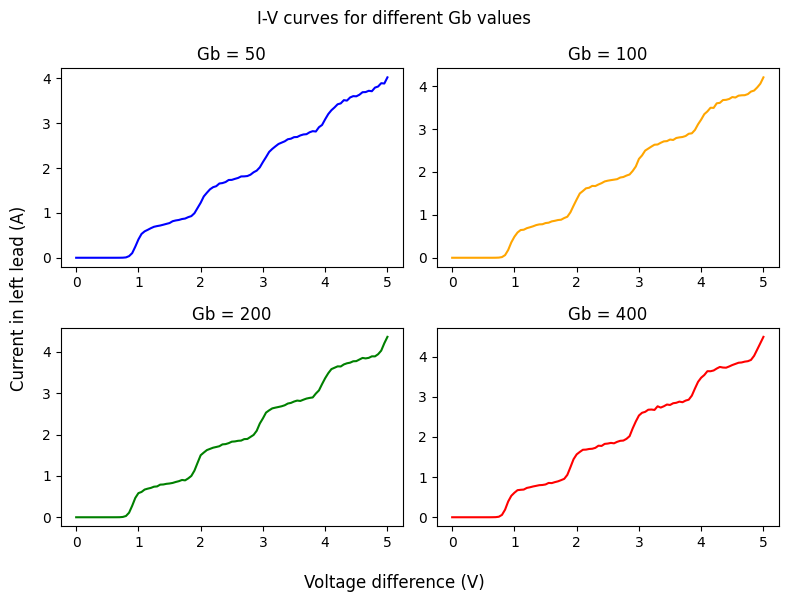

In [65]:
# Create figure with 2x2 grid of subplots
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle('I-V curves for different Gb values')
fig.supxlabel('Voltage difference (V)')
fig.supylabel('Current in left lead (A)')
voltages=np.linspace(0,Vmax, num=Numsteps+1)

# Plot on each subplot using ax[row][col] or ax[row, col]
ax[0, 0].plot(voltages, currents[0], color='blue')
ax[0, 0].set_title('Gb = 50')

ax[0, 1].plot(voltages, currents[1], color='orange')
ax[0, 1].set_title('Gb = 100')

ax[1, 0].plot(voltages, currents[2], color='green')
ax[1, 0].set_title('Gb = 200')

ax[1, 1].plot(voltages, currents[3], color='red')
ax[1, 1].set_title('Gb = 400')

plt.tight_layout()          # prevents overlapping labels
plt.savefig('plots.png', dpi=150)
plt.show()

In [56]:
#let us take an I-Vcurve from 0 to 20 with 1000 steps, time interval 1000. Took about 15 min for N=8 T=0.27
zeros=np.zeros(2)

voltages=np.linspace(0,Vmax, num=Numsteps+1)
# a long run of simulation cycles
listofcurrents=Setup.runit(Numsteps,zeros,zeros,np.array([Vmax/2,-Vmax/2]),zeros,timeinterval=1000,debug=True)
listofcurrents = np.array(listofcurrents)

Run 1
CPU time: 0.0 Simulated time: 692572831856.9 Events: 5 Cache: 5
Run 2
CPU time: 0.0 Simulated time: 899589123780.6 Events: 2 Cache: 2
Run 3
CPU time: 0.0 Simulated time: 1074780829.1 Events: 2 Cache: 2
Run 4
CPU time: 0.0 Simulated time: 21142981285.6 Events: 2 Cache: 2
Run 5
CPU time: 0.0 Simulated time: 5552972464.7 Events: 2 Cache: 2
Run 6
CPU time: 0.0 Simulated time: 2383985826.8 Events: 3 Cache: 3
Run 7
CPU time: 0.0 Simulated time: 350988342.9 Events: 2 Cache: 2
Run 8
CPU time: 0.0 Simulated time: 318949124.5 Events: 2 Cache: 2
Run 9
CPU time: 0.0 Simulated time: 4147971.6 Events: 2 Cache: 2
Run 10
CPU time: 0.0 Simulated time: 953921.0 Events: 2 Cache: 2
Run 11
CPU time: 0.0 Simulated time: 214531.5 Events: 2 Cache: 2
Run 12
CPU time: 0.0 Simulated time: 38304.1 Events: 2 Cache: 2
Run 13
CPU time: 0.0 Simulated time: 28271.0 Events: 2 Cache: 2
Run 14
CPU time: 0.0 Simulated time: 1939.0 Events: 2 Cache: 2
Run 15
CPU time: 0.0 Simulated time: 3112.0 Events: 6 Cache: 3
Run 

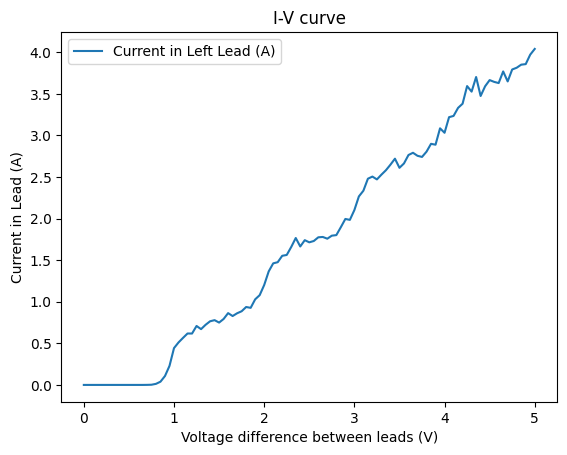

In [57]:
plt.plot(voltages,listofcurrents[:,0], label = 'Current in Left Lead (A)')
# plt.plot(voltages,listofcurrents[:,1], label = 'Current in Right Lead (A)')

plt.xlabel('Voltage difference between leads (V)')
plt.ylabel('Current in Lead (A)')
plt.title('I-V curve')
plt.legend()
plt.show()


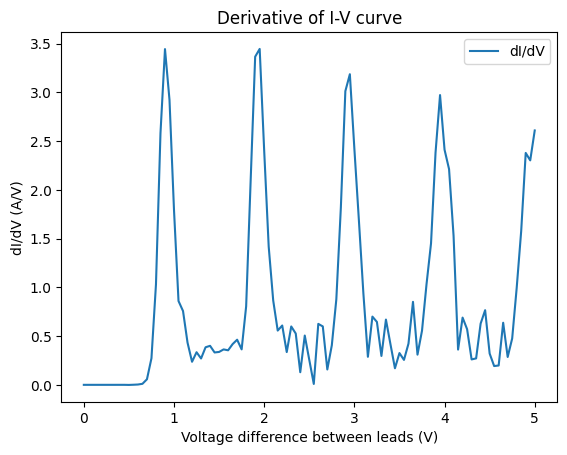

In [15]:
#derivative of the I-V curve
dIdV = np.gradient(listofcurrents[:,0], voltages)
plt.plot(voltages, dIdV, label='dI/dV')
plt.xlabel('Voltage difference between leads (V)')
plt.ylabel('dI/dV (A/V)')
plt.title('Derivative of I-V curve')
plt.legend()
plt.show()